# import libraries

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    silhouette_score,
)


plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid", font_scale=1.1)


In [2]:
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9+# ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

## Load data

In [3]:
# Đặt đúng đường dẫn file trước khi chạy
JOB_POSTINGS_PATH = "../../data/postings.csv"
COMPANIES_PATH = "../../data/companies.csv"
EMP_COUNTS_PATH = "../../data/employee_counts.csv"
JOB_SKILLS_PATH = "../../data/job_skills.csv"
SKILL_MAP_PATH = "../../data/skill_mapping.csv"

job_df = pd.read_csv(JOB_POSTINGS_PATH)
companies_df = pd.read_csv(COMPANIES_PATH)
emp_counts_df = pd.read_csv(EMP_COUNTS_PATH)
job_skills_df = pd.read_csv(JOB_SKILLS_PATH)
skill_map_df = pd.read_csv(SKILL_MAP_PATH)


In [4]:
# Gộp để lấy tên kỹ năng đầy đủ
job_skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

# Gom danh sách kỹ năng theo từng job_id
skills_per_job = (
    job_skills_full.dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"skill_name": "linkedin_skills"})
)

## Tích hợp dữ liệu

In [5]:
# Merge job với thông tin công ty
job_merged = job_df.merge(companies_df, on="company_id", how="left")

# Sau khi merge, có thể xuất hiện description_x (job) và description_y (company)
# Chuẩn hóa lại để luôn có đúng một cột 'description' cho mô tả job
desc_cols = [c for c in job_merged.columns if "description" in c]
if "description" not in job_merged.columns:
    # Ưu tiên description_x nếu có (từ job_df)
    if "description_x" in job_merged.columns:
        job_merged["description"] = job_merged["description_x"]
    elif len(desc_cols) > 0:
        job_merged["description"] = job_merged[desc_cols[0]]
# Xóa các cột description trùng lặp khác (giữ lại 'description')
for c in desc_cols:
    if c != "description":
        job_merged.drop(columns=[c], inplace=True)

# Lấy bản ghi employee_count mới nhất cho mỗi công ty
emp_latest = emp_counts_df.sort_values("time_recorded").groupby("company_id").tail(1)
job_merged = job_merged.merge(
    emp_latest[["company_id", "employee_count", "follower_count"]],
    on="company_id",
    how="left",
)

# Merge skill vào job_merged
job_merged = job_merged.merge(skills_per_job, on="job_id", how="left")

print("Kích thước sau khi merge:", job_merged.shape)
job_merged.head()

Kích thước sau khi merge: (123849, 42)


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,state,country,city,zip_code_y,address,url,description,employee_count,follower_count,linkedin_skills
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,...,NJ,US,Jersey City,07302,242 Tenth Street,https://www.linkedin.com/company/corcoran-sawy...,Job descriptionA leading real estate firm in N...,402.0,2351.0,"[Marketing, Sales]"
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...",NaN,NaN,[Health Care Provider]
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,...,Ohio,US,Mariemont,45227,6880 Wooster Pike,https://www.linkedin.com/company/the-national-...,The National Exemplar is accepting application...,15.0,40.0,"[Management, Manufacturing]"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,...,New York,US,Lake Success,11042,3 Dakota Drive,https://www.linkedin.com/company/abrams-fenste...,Senior Associate Attorney - Elder Law / Trusts...,222.0,2427.0,[Other]
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Looking for HVAC service tech with experience ...,NaN,NaN,[Information Technology]


##  Tiền xử lí dữ liệu

In [6]:
# tạo cột mới chuẩn hóa description
job_merged["description_norm"] = (
    job_merged["description"].fillna("").apply(normalize_text)
)

# RQ1  

## Chuẩn bị dữ liệu

In [55]:
TEXT_COL = "description_norm"
job_text = job_merged[["job_id", "title", TEXT_COL]].dropna(subset=[TEXT_COL]).copy()

# Sample để chạy nhanh (tuỳ RAM/CPU)
MAX_DOCS = 20000
if len(job_text) > MAX_DOCS:
    job_text_sample = job_text.sample(MAX_DOCS, random_state=42).reset_index(drop=True)
else:
    job_text_sample = job_text.reset_index(drop=True)

print("Số JD dùng cho RQ1 clustering:", len(job_text_sample))

Số JD dùng cho RQ1 clustering: 20000


## TF-IDF vectorization (themes)

In [29]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=10,  # bỏ từ quá hiếm
    max_df=0.80,  # bỏ từ quá phổ biến (boilerplate)
)
X = tfidf.fit_transform(job_text_sample[TEXT_COL])
print("TF-IDF matrix:", X.shape)

TF-IDF matrix: (20000, 30000)


## Chạy K-Means

In [30]:
def top_terms_per_cluster(model, vectorizer, n_terms=15):
    terms = np.array(vectorizer.get_feature_names_out())
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    cluster_terms = {}
    for i in range(model.n_clusters):
        cluster_terms[i] = terms[order_centroids[i, :n_terms]]
    return cluster_terms

In [31]:
SIL_SAMPLE = 10000
if X.shape[0] > SIL_SAMPLE:
    rng = np.random.RandomState(42)
    idx_sil = rng.choice(X.shape[0], size=SIL_SAMPLE, replace=False)
    X_sil = X[idx_sil]
else:
    X_sil = X

**Lý do lựa chọn tập giá trị K**

Các giá trị K ∈ {5, 10, 15, 20, 25, 30} được lựa chọn để đại diện cho các mức độ chi tiết khác nhau của chủ đề nội dung trong mô tả công việc, từ tổng quát đến chi tiết hơn. Cách lựa chọn này giúp quan sát xu hướng thay đổi chất lượng phân cụm theo K mà không tối ưu hóa quá mức tham số. Việc chọn K ưu tiên khả năng diễn giải và ý nghĩa thực tế của các cụm hơn là tối ưu thuần túy theo chỉ số.


In [32]:
k_list = [5, 10, 15, 20, 25, 30]

silhouette_rows = []
keywords_by_k = {}

for k in k_list:
    print(f"\n===== Running KMeans with k={k} =====")
    
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sil)
    
    sil = silhouette_score(X_sil, labels)
    silhouette_rows.append({"k": k, "silhouette": sil})
    
    print(f"Silhouette score: {sil:.6f}")
    
    # Lấy top keywords cho từng cluster
    cluster_keywords = top_terms_per_cluster(km, tfidf, n_terms=15)
    
    # Lưu vào dict theo k
    keywords_by_k[k] = {
        int(cid): kws.tolist()
        for cid, kws in cluster_keywords.items()
    }
    
    # In nhanh để kiểm tra
    for cid, kws in cluster_keywords.items():
        print(f"  Cluster {cid}: {', '.join(kws[:8])}")

results_df = pd.DataFrame(silhouette_rows).sort_values("k")



===== Running KMeans with k=5 =====
Silhouette score: 0.007542
  Cluster 0: care, patient, patients, nursing, health, nurse, healthcare, medical
  Cluster 1: job, required, service, equipment, company, team, ability, time
  Cluster 2: project, data, design, business, management, team, engineering, development
  Cluster 3: sales, marketing, business, customer, team, customers, market, new
  Cluster 4: store, customer, sales, customers, merchandise, retail, associates, service

===== Running KMeans with k=10 =====
Silhouette score: 0.013830
  Cluster 0: data, design, software, security, cloud, technical, systems, development
  Cluster 1: business, team, management, customer, company, skills, including, support
  Cluster 2: care, patient, patients, nursing, health, nurse, medical, healthcare
  Cluster 3: accounting, financial, tax, finance, capital, business, clients, reporting
  Cluster 4: team, job, time, students, position, skills, health, service
  Cluster 5: sales, marketing, busine

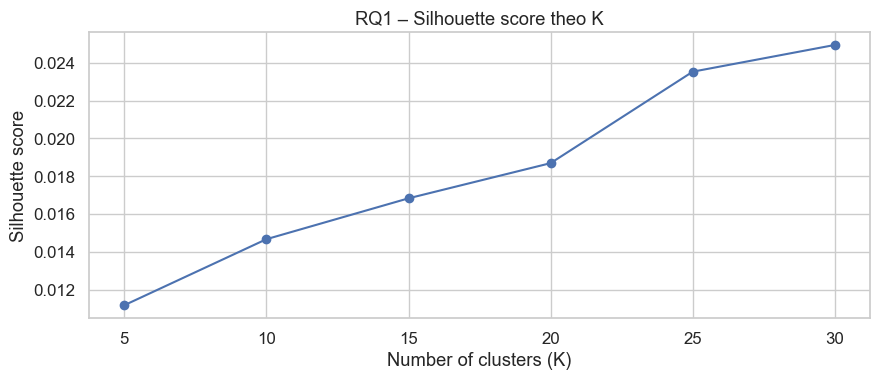

In [12]:
plt.figure(figsize=(9,4))
plt.plot(results_df["k"], results_df["silhouette"], marker="o")
plt.title("RQ1 – Silhouette score theo K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.tight_layout()

In [34]:

kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
job_text_sample["cluster"] = kmeans.fit_predict(X)
job_text_sample.head()

,job_id,title,description_norm,cluster
0,3902944011,Senior Automation Engineer - Power Systems,the senior automation power systems engineer w...,3
1,3901960222,DISH Installation Technician - Field,company summary dish an echostar company has b...,13
2,3900944095,Order Builder,division north alabama department oxford wareh...,2
3,3903878594,"Mountain Multimedia Journalist, KMGH",kmgh the e w scripps company abc affiliate in ...,13
4,3905670593,Licensed Practical Nurse (LPN),come for the flexibility stay for the culture ...,14


In [14]:
cluster_keywords = top_terms_per_cluster(kmeans, tfidf, n_terms=15)

print("\nTop keywords per cluster:")
for cid, kws in cluster_keywords.items():
    print(f"Cluster {cid}: {', '.join(kws[:10])}")


Top keywords per cluster:
Cluster 0: design, software, technical, engineering, security, systems, development, cloud, solutions, product
Cluster 1: students, student, school, learning, teaching, teacher, classroom, teachers, education, curriculum
Cluster 2: store, customer, sales, merchandise, customers, retail, store manager, service, manager, associates
Cluster 3: team, business, management, skills, company, job, customer, support, including, benefits
Cluster 4: equipment, safety, maintenance, required, ability, job, perform, company, duties, service
Cluster 5: accounting, financial, tax, finance, reporting, accountant, accounts, monthly, analysis, degree accounting
Cluster 6: care, nursing, patient, nurse, patients, rn, health, patient care, registered, registered nurse
Cluster 7: project, construction, projects, engineering, management, design, project management, project manager, team, client
Cluster 8: marketing, media, content, digital, social, social media, brand, campaigns, c

In [15]:
job_merged.columns

Index(['job_id', 'company_name', 'title', 'max_salary', 'pay_period',
       'location', 'company_id', 'views', 'med_salary', 'min_salary',
       'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code_x', 'fips', 'name',
       'company_size', 'state', 'country', 'city', 'zip_code_y', 'address',
       'url', 'description', 'employee_count', 'follower_count',
       'linkedin_skills', 'description_norm'],
      dtype='object')

# Đánh giá hậu nghiệm

In [43]:
# ==== Load industries tables ====
JOB_INDUSTRIES_PATH = "../../data/job_industries.csv"
INDUSTRIES_PATH     = "../../data/industries.csv"

job_industries_df = pd.read_csv(JOB_INDUSTRIES_PATH)   # job_id, industry_id
industries_df     = pd.read_csv(INDUSTRIES_PATH)       # industry_id, industry_name

# ==== Join để lấy industry_name cho mỗi job ====
job_ind_full = job_industries_df.merge(
    industries_df, on="industry_id", how="left"
)

# job_text_sample MUST have: job_id, cluster
assert "job_id" in job_text_sample.columns, "job_text_sample thiếu cột job_id"
assert "cluster" in job_text_sample.columns, "job_text_sample thiếu cột cluster (chạy KMeans trước)"

cluster_ind_df = (
    job_text_sample[["job_id", "cluster"]]
    .merge(job_ind_full[["job_id", "industry_name"]], on="job_id", how="left")
)

cluster_ind_df["industry_name"] = cluster_ind_df["industry_name"].fillna("Unknown")
cluster_ind_df.head()


,job_id,cluster,industry_name
0,3902944011,3,Oil and Gas
1,3901960222,13,Telecommunications
2,3900944095,2,Manufacturing
3,3903878594,13,Broadcast Media Production and Distribution
4,3905670593,14,Hospitals and Health Care


In [44]:
cluster_industry_dist = (
    cluster_ind_df
    .groupby(["cluster", "industry_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)

TOP_N = 5
top_ind_by_cluster = cluster_industry_dist.groupby("cluster").head(TOP_N)
top_ind_by_cluster.head(30)


,cluster,industry_name,count
68,0,IT Services and IT Consulting,646
136,0,Software Development,308
51,0,Financial Services,151
142,0,Staffing and Recruiting,102
78,0,Information Services,78
164,1,Accounting,170
210,1,Financial Services,80
281,1,Staffing and Recruiting,71
240,1,Manufacturing,48
265,1,Real Estate,34


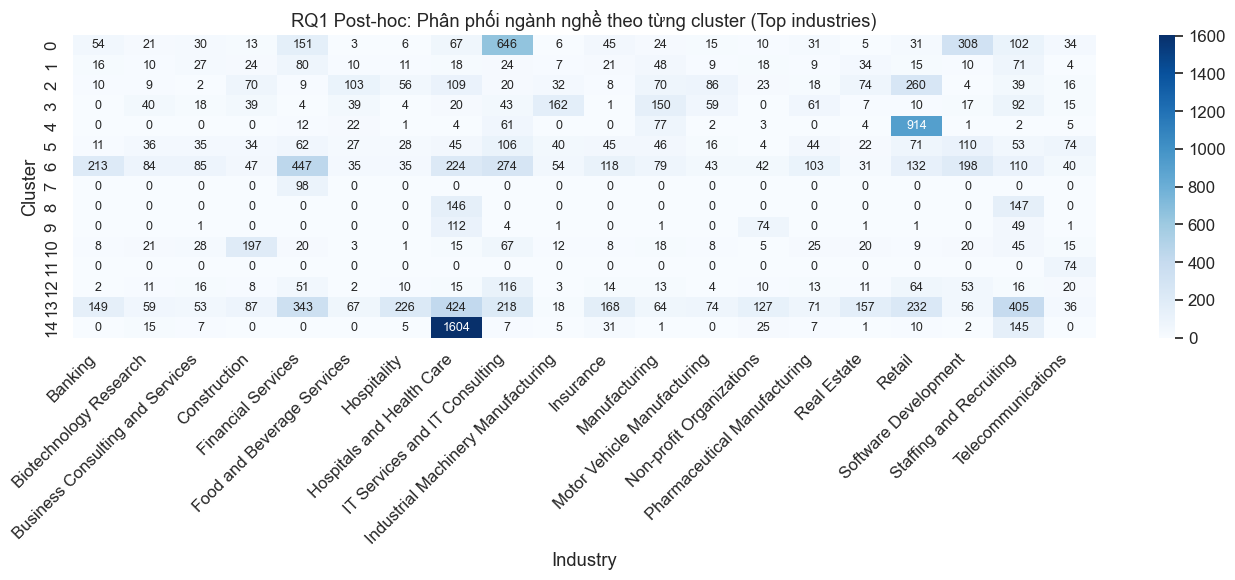

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

TOP_INDUSTRIES = 20
top_industries = (
    cluster_industry_dist.groupby("industry_name")["count"].sum()
    .sort_values(ascending=False)
    .head(TOP_INDUSTRIES)
    .index
)

heat_df = cluster_industry_dist[cluster_industry_dist["industry_name"].isin(top_industries)]

pivot = heat_df.pivot_table(
    index="cluster",
    columns="industry_name",
    values="count",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot,
    cmap="Blues",
    annot=True,          # HIỆN SỐ
    fmt=".0f",           # số nguyên
    annot_kws={"size": 9}
)
plt.xticks(rotation=45, ha="right")
plt.title("RQ1 Post-hoc: Phân phối ngành nghề theo từng cluster (Top industries)")
plt.xlabel("Industry")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()
